# Spam Classification — Comparaison de modèles scikit-learn

**Objectif :** Classifier les e-mails en spam (1) ou non-spam (0) en comparant plusieurs modèles scikit-learn et en sélectionnant le plus performant.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
)

# Modèles
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# Chargement du dataset
df = pd.read_csv("spam_or_not_spam.csv")
df.dropna(inplace=True)
df["email"] = df["email"].astype(str)

print("Shape:", df.shape)
print("\nDistribution des classes:")
print(df["label"].value_counts())
print(f"\nPourcentage spam: {df['label'].mean()*100:.1f}%")

Shape: (2999, 2)

Distribution des classes:
label
0    2500
1     499
Name: count, dtype: int64

Pourcentage spam: 16.6%


## 1. Exploration des données (EDA)

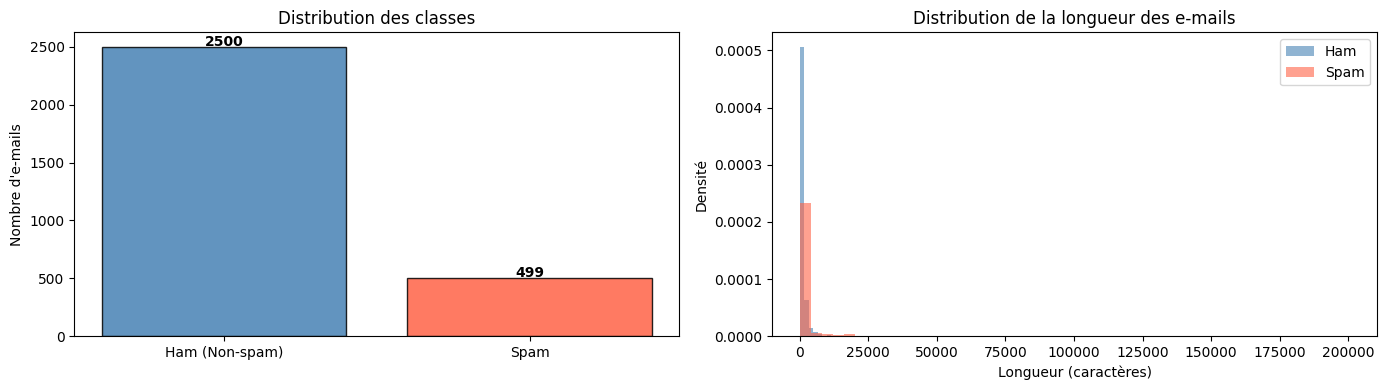

        count         mean          std  min    25%    50%      75%       max
label                                                                        
Ham    2500.0  1233.672000  3101.999287  5.0  360.0  719.0  1280.25   82994.0
Spam    499.0  2313.669339  9817.766265  1.0  525.0  956.0  1941.00  200408.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution des classes
label_names = {0: "Ham (Non-spam)", 1: "Spam"}
counts = df["label"].value_counts().sort_index()
axes[0].bar([label_names[i] for i in counts.index], counts.values,
            color=["steelblue", "tomato"], edgecolor="k", alpha=0.85)
axes[0].set_title("Distribution des classes")
axes[0].set_ylabel("Nombre d'e-mails")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Distribution de la longueur des textes
df["text_len"] = df["email"].apply(len)
for label, color, name in [(0, "steelblue", "Ham"), (1, "tomato", "Spam")]:
    subset = df[df["label"] == label]["text_len"]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
axes[1].set_title("Distribution de la longueur des e-mails")
axes[1].set_xlabel("Longueur (caractères)")
axes[1].set_ylabel("Densité")
axes[1].legend()

plt.tight_layout()
plt.show()
print(df.groupby("label")["text_len"].describe().rename(index={0: "Ham", 1: "Spam"}))

## 2. Préprocessing — Train/Test split + TF-IDF

In [15]:
X = df["email"]
y = df["label"]

# Stratified split pour conserver les proportions spam/ham
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} exemples  |  Test: {len(X_test)} exemples")
print(f"  Spam dans train : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Spam dans test  : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Le TF-IDF vectorizer est inclus dans chaque pipeline pour éviter les fuites de données
tfidf_params = dict(
    ngram_range=(1, 2),  # unigrams + bigrams
    max_features=30_000,
    sublinear_tf=True,   # log(1+TF) pour réduire l'impact des termes trop fréquents
    strip_accents="unicode",
    analyzer="word",
    token_pattern=r"\w{2,}",
    min_df=2,
)

Train: 2399 exemples  |  Test: 600 exemples
  Spam dans train : 399 (16.6%)
  Spam dans test  : 100 (16.7%)


## 3. Comparaison de plusieurs modèles (Cross-Validation 5-fold)

In [16]:
# QDA nécessite une matrice dense : on réduit les dimensions avec TruncatedSVD (LSA)
# avant de passer à QDA. Les autres modèles utilisent directement le TF-IDF sparse.
def make_pipeline(clf, dense=False):
    steps = [("tfidf", TfidfVectorizer(**tfidf_params))]
    if dense:
        steps += [
            ("svd", TruncatedSVD(n_components=200, random_state=42)),
            ("norm", Normalizer()),
        ]
    steps.append(("clf", clf))
    return Pipeline(steps)

models = {
    "Naive Bayes (Multinomial)": (MultinomialNB(alpha=0.1),                                False),
    "Logistic Regression":       (LogisticRegression(C=5, max_iter=1000, solver="lbfgs",
                                                     class_weight="balanced"),             False),
    "SGD Classifier":            (SGDClassifier(loss="modified_huber", max_iter=1000,
                                                random_state=42, class_weight="balanced"), False),
    "Random Forest":             (RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                         random_state=42,
                                                         class_weight="balanced"),         False),
    "QDA":                       (QuadraticDiscriminantAnalysis(),                         True),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, (clf, dense) in models.items():
    pipeline = make_pipeline(clf, dense=dense)
    # Score F1 macro (équilibre entre précision et rappel, robuste aux classes déséquilibrées)
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv, scoring="f1_macro", n_jobs=-1)
    results.append({"Modèle": name, "F1-macro moyen": scores.mean(), "Écart-type": scores.std()})
    print(f"{name:<30}  F1-macro = {scores.mean():.4f} ± {scores.std():.4f}")

results_df = pd.DataFrame(results).sort_values("F1-macro moyen", ascending=False).reset_index(drop=True)
best_model_name = results_df.iloc[0]["Modèle"]
print(f"\n✅ Meilleur modèle en CV : {best_model_name}")

Naive Bayes (Multinomial)       F1-macro = 0.9832 ± 0.0052
Logistic Regression             F1-macro = 0.9886 ± 0.0024
SGD Classifier                  F1-macro = 0.9887 ± 0.0053
Random Forest                   F1-macro = 0.9672 ± 0.0072
QDA                             F1-macro = 0.9142 ± 0.0095

✅ Meilleur modèle en CV : SGD Classifier


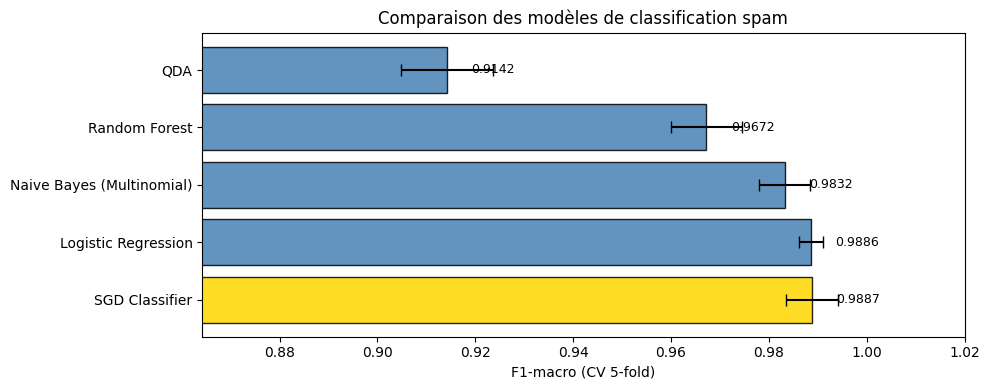

                   Modèle  F1-macro moyen  Écart-type
           SGD Classifier        0.988730    0.005335
      Logistic Regression        0.988608    0.002370
Naive Bayes (Multinomial)        0.983191    0.005200
            Random Forest        0.967218    0.007209
                      QDA        0.914187    0.009470


In [17]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["gold" if i == 0 else "steelblue" for i in range(len(results_df))]
bars = ax.barh(results_df["Modèle"], results_df["F1-macro moyen"],
               xerr=results_df["Écart-type"], color=colors,
               edgecolor="k", alpha=0.85, capsize=4)
ax.set_xlabel("F1-macro (CV 5-fold)")
ax.set_title("Comparaison des modèles de classification spam")
ax.set_xlim(results_df["F1-macro moyen"].min() - 0.05, 1.02)
for bar, val in zip(bars, results_df["F1-macro moyen"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()
print(results_df.to_string(index=False))

## 4. Évaluation finale du meilleur modèle sur le jeu de test

=== Modèle sélectionné : SGD Classifier ===

Accuracy  : 0.9950
F1-macro  : 0.9909
ROC-AUC   : 0.9937

              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       500
        Spam       1.00      0.97      0.98       100

    accuracy                           0.99       600
   macro avg       1.00      0.98      0.99       600
weighted avg       1.00      0.99      0.99       600



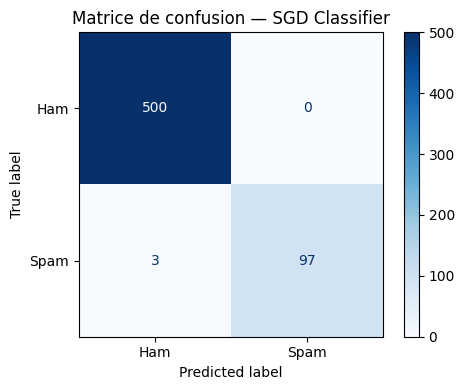

In [18]:
# Entraînement du meilleur modèle sur tout le train set
best_clf, best_dense = models[best_model_name]
best_pipeline = make_pipeline(best_clf, dense=best_dense)
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

# Probabilités (ou scores) pour ROC-AUC
if hasattr(best_clf, "predict_proba"):
    y_scores = best_pipeline.predict_proba(X_test)[:, 1]
else:
    y_scores = best_pipeline.decision_function(X_test)

print(f"=== Modèle sélectionné : {best_model_name} ===\n")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-macro  : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_scores):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Ham", "Spam"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Matrice de confusion — {best_model_name}")
plt.tight_layout()
plt.show()

## 5. Prédiction sur de nouveaux e-mails

In [19]:
sample_emails = [
    "Congratulations! You have won a FREE iPhone. Click here to claim your prize now!!!",
    "Hi John, just checking if we are still on for our meeting tomorrow at 10am. Let me know.",
    "URGENT: Your bank account has been compromised. Verify immediately at http://fakebank.com",
    "Please find attached the report from last week's sprint review. Let me know if you have questions.",
    "You have been selected for a limited-time offer. Buy now and get 90% discount!!!",
]

preds = best_pipeline.predict(sample_emails)
if hasattr(best_clf, "predict_proba"):
    probs = best_pipeline.predict_proba(sample_emails)[:, 1]
else:
    scores = best_pipeline.decision_function(sample_emails)
    probs = (scores - scores.min()) / (scores.max() - scores.min())  # normalize 0-1

print("=" * 70)
for email, pred, prob in zip(sample_emails, preds, probs):
    label = "🚨 SPAM" if pred == 1 else "✅ HAM "
    print(f"{label}  (score spam: {prob:.3f})")
    print(f"  → {email[:80]}...")
    print()
print("=" * 70)

🚨 SPAM  (score spam: 1.000)
  → Congratulations! You have won a FREE iPhone. Click here to claim your prize now!...

✅ HAM   (score spam: 0.472)
  → Hi John, just checking if we are still on for our meeting tomorrow at 10am. Let ...

🚨 SPAM  (score spam: 0.762)
  → URGENT: Your bank account has been compromised. Verify immediately at http://fak...

🚨 SPAM  (score spam: 0.523)
  → Please find attached the report from last week's sprint review. Let me know if y...

🚨 SPAM  (score spam: 1.000)
  → You have been selected for a limited-time offer. Buy now and get 90% discount!!!...

